# Carry 因子分析 & 多因子组合

研究内容：
1. Carry 信号可视化 — 每个品种的期限结构状态
2. Carry vs 趋势信号相关性 — 验证"不同数据源 = 低相关"的假设
3. Carry 单独回测 — 独立绩效评估
4. Carry + 趋势组合 — 多因子融合效果

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from cta.data_loader import load_multiple, load_carry_data
from cta.signals import carry, generate_signal, SIGNAL_REGISTRY
from cta.position_sizing import volatility_sized_position
from cta.backtest import run_backtest
from cta.analysis import calc_metrics

data_dir = Path("../data/raw")

# 品种配置
PRODUCTS = {
    "ES": {"point_value": 50.0, "commission": 2.5, "slippage_points": 0.25},
    "CL": {"point_value": 1000.0, "commission": 2.5, "slippage_points": 0.02},
    "GC": {"point_value": 100.0, "commission": 2.5, "slippage_points": 0.10},
    "ZN": {"point_value": 1000.0, "commission": 2.5, "slippage_points": 0.01},
}

INITIAL_CAPITAL = 1_000_000

# 加载数据
price_data = load_multiple(data_dir)       # ratio/panama adjusted OHLCV
carry_data = load_carry_data(data_dir)     # raw front/back close

print("Price data:", list(price_data.keys()))
print("Carry data:", list(carry_data.keys()))
for name, df in carry_data.items():
    print(f"  {name}: {len(df)} days, front={df['front_close'].iloc[-1]:.2f}, back={df['back_close'].iloc[-1]:.2f}")

Price data: ['CL', 'ES', 'GC', 'ZN']
Carry data: ['CL', 'ES', 'GC', 'ZN']
  CL: 2253 days, front=106.21, back=98.95
  ES: 2255 days, front=6373.00, back=6420.00
  GC: 1937 days, front=4508.90, back=4521.80
  ZN: 2116 days, front=110.77, back=110.61


## 1. Carry 信号可视化

原始 carry = (front - back) / front：
- 正值 = backwardation（近月贵于远月）→ 做多有利
- 负值 = contango（远月贵于近月）→ 做空有利

归一化后的 carry 信号在 [-1, +1] 范围内。

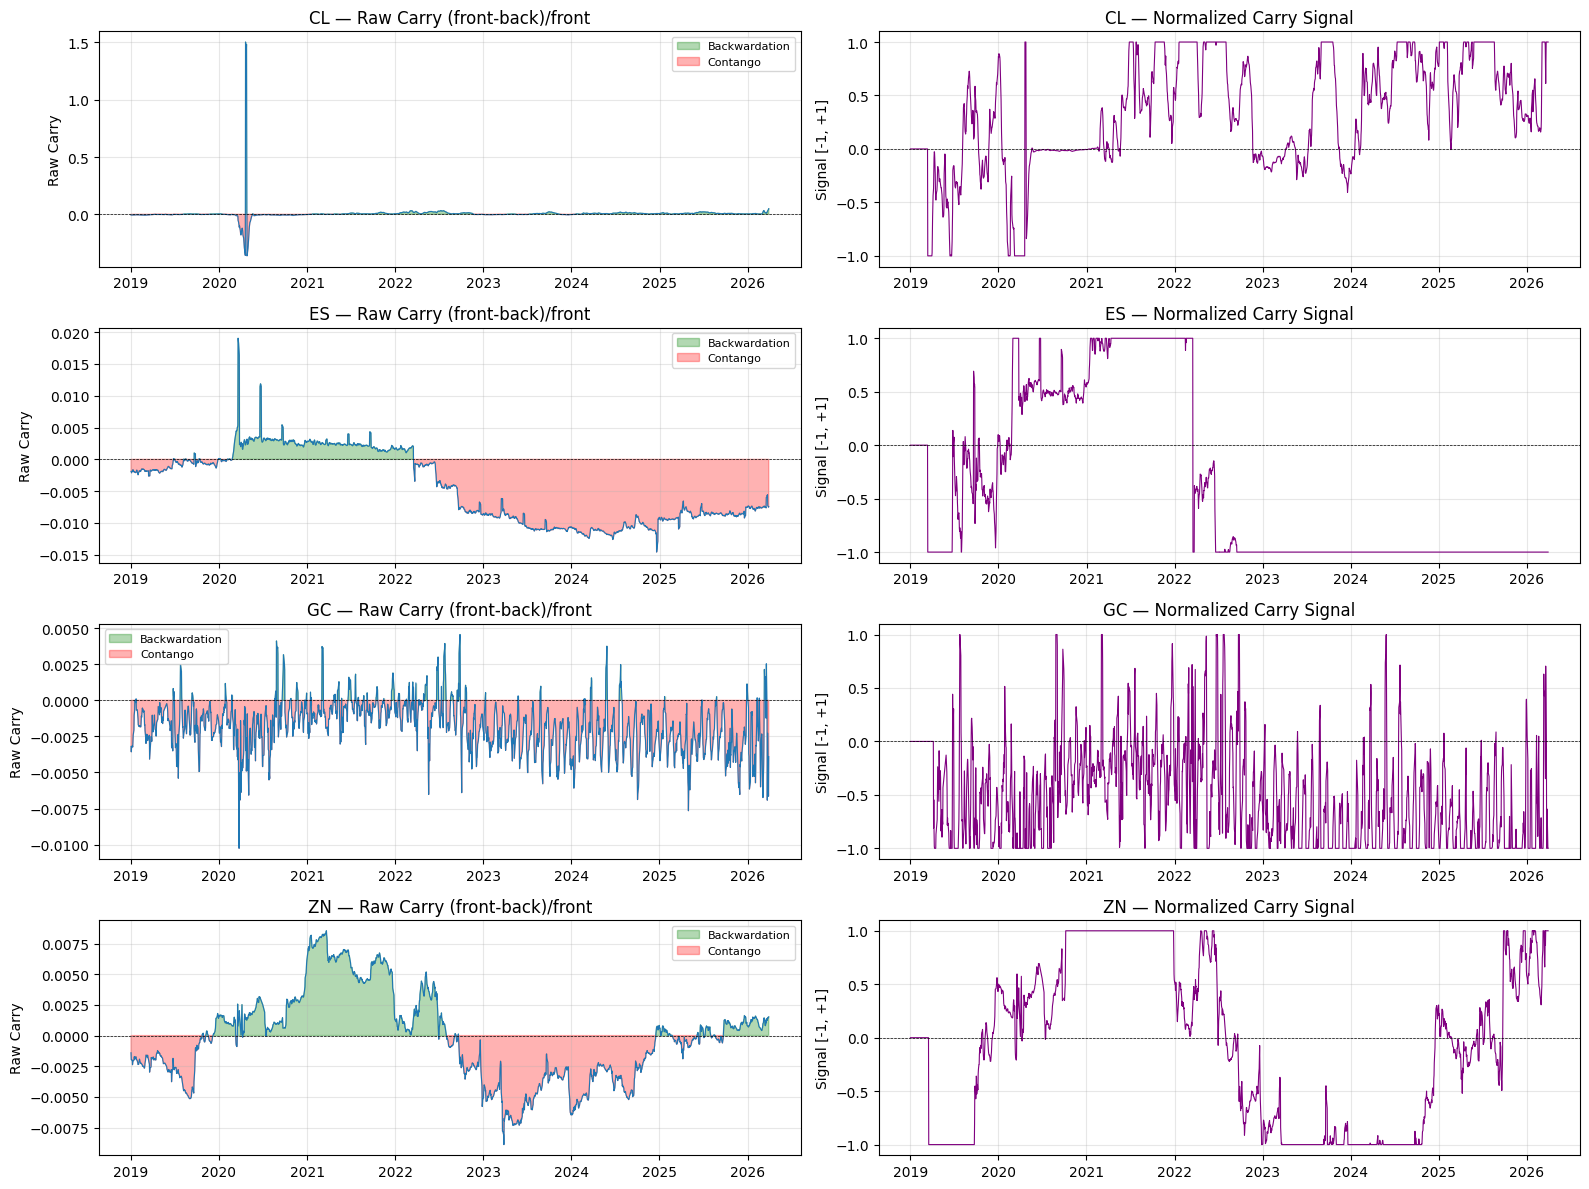

In [2]:
# 计算每个品种的 carry 信号
carry_signals = {}
raw_carry_values = {}

for name, df in carry_data.items():
    # 原始 carry（未归一化）
    raw = (df["front_close"] - df["back_close"]) / df["front_close"].replace(0, np.nan)
    raw_carry_values[name] = raw.rolling(5, min_periods=1).mean()
    
    # 归一化 carry 信号 [-1, +1]
    carry_signals[name] = carry(df["front_close"], df["back_close"])

# 可视化：原始 carry 值 + 归一化信号
fig, axes = plt.subplots(len(carry_data), 2, figsize=(16, 3 * len(carry_data)), sharex=False)

for i, name in enumerate(sorted(carry_data.keys())):
    # 左图：原始 carry
    ax = axes[i, 0]
    raw = raw_carry_values[name].dropna()
    ax.plot(raw.index, raw.values, linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.fill_between(raw.index, raw.values, 0, 
                    where=raw.values > 0, alpha=0.3, color="green", label="Backwardation")
    ax.fill_between(raw.index, raw.values, 0,
                    where=raw.values < 0, alpha=0.3, color="red", label="Contango")
    ax.set_ylabel("Raw Carry")
    ax.set_title(f"{name} — Raw Carry (front-back)/front")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # 右图：归一化信号
    ax = axes[i, 1]
    sig = carry_signals[name].dropna()
    ax.plot(sig.index, sig.values, linewidth=0.8, color="purple")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel("Signal [-1, +1]")
    ax.set_title(f"{name} — Normalized Carry Signal")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Carry vs 趋势信号相关性

项目二发现：10 个趋势信号之间相关性 0.5-0.9，因为它们都用价格时间序列作为输入。

Carry 用的是期限结构（近月 vs 远月价差），理论上应该和趋势信号低相关。

验证方法：计算 carry 信号与每个趋势信号的相关系数，预期 < 0.3。

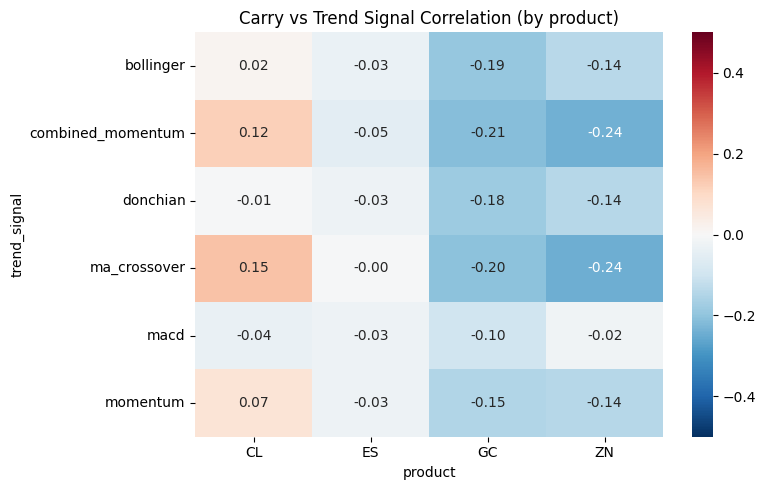


Average |correlation| of carry vs each trend signal:
  momentum             avg=-0.064  avg|r|=0.097
  combined_momentum    avg=-0.097  avg|r|=0.156
  macd                 avg=-0.046  avg|r|=0.046
  ma_crossover         avg=-0.076  avg|r|=0.150
  donchian             avg=-0.089  avg|r|=0.089
  bollinger            avg=-0.088  avg|r|=0.095


In [3]:
# 选几个代表性趋势信号
trend_signal_names = ["momentum", "combined_momentum", "macd", "ma_crossover", "donchian", "bollinger"]

# 对每个品种，计算 carry 与趋势信号的相关性
corr_records = []

for product_name in sorted(carry_signals.keys()):
    if product_name not in price_data:
        continue
    
    daily = price_data[product_name]
    c_sig = carry_signals[product_name]
    
    for t_name in trend_signal_names:
        t_sig = generate_signal(daily, t_name)
        
        # 对齐索引
        common = c_sig.index.intersection(t_sig.index)
        if len(common) < 100:
            continue
        
        corr = c_sig.loc[common].corr(t_sig.loc[common])
        corr_records.append({
            "product": product_name,
            "trend_signal": t_name,
            "correlation": corr,
        })

corr_df = pd.DataFrame(corr_records)
corr_pivot = corr_df.pivot(index="trend_signal", columns="product", values="correlation")

# 热力图
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, 
            vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title("Carry vs Trend Signal Correlation (by product)")
plt.tight_layout()
plt.show()

# 平均相关性
print("\nAverage |correlation| of carry vs each trend signal:")
for t_name in trend_signal_names:
    subset = corr_df[corr_df["trend_signal"] == t_name]
    avg_abs = subset["correlation"].abs().mean()
    avg = subset["correlation"].mean()
    print(f"  {t_name:<20} avg={avg:+.3f}  avg|r|={avg_abs:.3f}")

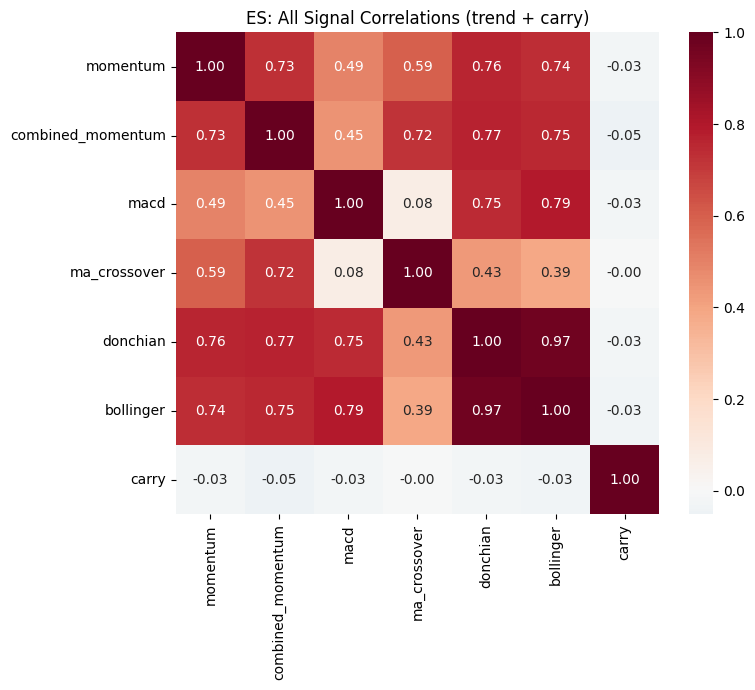

Trend-Trend avg |correlation|: 0.626
Carry-Trend avg |correlation|: 0.028

→ Carry provides significant diversification


In [4]:
# 对比：趋势信号之间的相关性 vs carry与趋势的相关性
# 以 ES 为例
daily_es = price_data["ES"]

all_signals_es = {}
for t_name in trend_signal_names:
    all_signals_es[t_name] = generate_signal(daily_es, t_name)
all_signals_es["carry"] = carry_signals["ES"]

sig_df = pd.DataFrame(all_signals_es).dropna()
full_corr = sig_df.corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(full_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("ES: All Signal Correlations (trend + carry)")
plt.tight_layout()
plt.show()

# carry 与趋势的平均相关性 vs 趋势之间的平均相关性
trend_corrs = []
carry_corrs = []
for i, s1 in enumerate(trend_signal_names):
    for s2 in trend_signal_names[i+1:]:
        trend_corrs.append(abs(full_corr.loc[s1, s2]))
    carry_corrs.append(abs(full_corr.loc["carry", s1]))

print(f"Trend-Trend avg |correlation|: {np.mean(trend_corrs):.3f}")
print(f"Carry-Trend avg |correlation|: {np.mean(carry_corrs):.3f}")
print(f"\n→ Carry provides {'significant' if np.mean(carry_corrs) < 0.3 else 'moderate'} diversification")

## 3. Carry 单独回测

用 carry 信号独立跑回测，评估其作为单因子的表现。
使用和趋势策略相同的回测框架：ATR-based position sizing + vectorized backtest。

In [5]:
def backtest_signal_portfolio(signal_dict, price_data, products_config, initial_capital=1_000_000):
    """对一组品种信号跑回测，返回组合权益曲线和各品种 metrics。
    
    signal_dict: {product_name: signal_series}
    """
    n_products = len(signal_dict)
    all_net_pnl = {}
    product_metrics = {}
    
    for name, signal in signal_dict.items():
        if name not in price_data or name not in products_config:
            continue
        
        daily = price_data[name]
        params = products_config[name]
        
        # ATR-based position sizing
        position = volatility_sized_position(
            signal=signal,
            high=daily["high"],
            low=daily["low"],
            close=daily["close"],
            capital=initial_capital,
            risk_fraction=0.01 / n_products,
            point_value=params["point_value"],
            atr_period=20,
        )
        
        result = run_backtest(
            daily_price=daily,
            position=position,
            point_value=params["point_value"],
            commission_per_contract=params["commission"],
            slippage_points=params["slippage_points"],
            initial_capital=initial_capital,
        )
        
        all_net_pnl[name] = result["net_pnl"]
        product_metrics[name] = calc_metrics(result["equity"])
    
    # 组合
    pnl_df = pd.DataFrame(all_net_pnl).fillna(0)
    portfolio_pnl = pnl_df.sum(axis=1)
    portfolio_equity = initial_capital + portfolio_pnl.cumsum()
    portfolio_metrics = calc_metrics(portfolio_equity)
    
    return portfolio_equity, portfolio_metrics, product_metrics

In [6]:
# --- Carry-only backtest ---
carry_equity, carry_portfolio_metrics, carry_product_metrics = backtest_signal_portfolio(
    carry_signals, price_data, PRODUCTS
)

print("=== Carry-Only Portfolio ===")
print(f"  Sharpe:       {carry_portfolio_metrics['sharpe_ratio']:.2f}")
print(f"  Annual Return:{carry_portfolio_metrics['annual_return']:.2%}")
print(f"  Max Drawdown: {carry_portfolio_metrics['max_drawdown']:.2%}")
print(f"  Calmar:       {carry_portfolio_metrics['calmar_ratio']:.2f}")
print()

print("Per-product:")
for name, m in sorted(carry_product_metrics.items()):
    print(f"  {name}: Sharpe={m['sharpe_ratio']:.2f}, Return={m['annual_return']:.2%}, MaxDD={m['max_drawdown']:.2%}")

=== Carry-Only Portfolio ===
  Sharpe:       -1.30
  Annual Return:-12.34%
  Max Drawdown: -72.62%
  Calmar:       -0.17

Per-product:
  CL: Sharpe=0.08, Return=0.15%, MaxDD=-7.21%
  ES: Sharpe=-0.57, Return=-1.68%, MaxDD=-17.84%
  GC: Sharpe=-1.66, Return=-6.38%, MaxDD=-40.21%
  ZN: Sharpe=-0.78, Return=-2.06%, MaxDD=-18.88%


In [7]:
# --- Trend-only backtest (combined_momentum as baseline) ---
trend_signals = {}
for name in carry_signals.keys():
    if name in price_data:
        trend_signals[name] = generate_signal(price_data[name], "combined_momentum")

trend_equity, trend_portfolio_metrics, trend_product_metrics = backtest_signal_portfolio(
    trend_signals, price_data, PRODUCTS
)

print("=== Trend-Only Portfolio (combined_momentum) ===")
print(f"  Sharpe:       {trend_portfolio_metrics['sharpe_ratio']:.2f}")
print(f"  Annual Return:{trend_portfolio_metrics['annual_return']:.2%}")
print(f"  Max Drawdown: {trend_portfolio_metrics['max_drawdown']:.2%}")
print(f"  Calmar:       {trend_portfolio_metrics['calmar_ratio']:.2f}")

=== Trend-Only Portfolio (combined_momentum) ===
  Sharpe:       0.43
  Annual Return:2.30%
  Max Drawdown: -12.27%
  Calmar:       0.19


## 4. Carry + 趋势组合

核心问题：组合 carry 和趋势信号后，是否能获得比单因子更好的风险调整收益？

组合方式：
1. **等权融合**：final_signal = 0.5 × carry + 0.5 × trend
2. **偏趋势**：final_signal = 0.7 × trend + 0.3 × carry
3. **偏 carry**：final_signal = 0.3 × trend + 0.7 × carry

In [8]:
# 构建组合信号
blend_configs = {
    "50/50 (equal)":    (0.5, 0.5),
    "70/30 (trend)":    (0.7, 0.3),
    "30/70 (carry)":    (0.3, 0.7),
}

results_summary = {
    "Carry Only": carry_portfolio_metrics,
    "Trend Only": trend_portfolio_metrics,
}

equity_curves = {
    "Carry Only": carry_equity,
    "Trend Only": trend_equity,
}

for blend_name, (w_trend, w_carry) in blend_configs.items():
    blended_signals = {}
    for name in carry_signals.keys():
        if name not in price_data or name not in trend_signals:
            continue
        c_sig = carry_signals[name]
        t_sig = trend_signals[name]
        # 对齐索引
        common = c_sig.index.intersection(t_sig.index)
        blended = (w_trend * t_sig.loc[common] + w_carry * c_sig.loc[common]).clip(-1, 1)
        blended_signals[name] = blended
    
    eq, metrics, _ = backtest_signal_portfolio(blended_signals, price_data, PRODUCTS)
    results_summary[blend_name] = metrics
    equity_curves[blend_name] = eq

# 汇总表
summary_df = pd.DataFrame({
    name: {
        "Sharpe": m["sharpe_ratio"],
        "Annual Return": f"{m['annual_return']:.2%}",
        "Max Drawdown": f"{m['max_drawdown']:.2%}",
        "Calmar": m["calmar_ratio"],
    }
    for name, m in results_summary.items()
}).T

print(summary_df.to_string())
summary_df

                 Sharpe Annual Return Max Drawdown    Calmar
Carry Only    -1.304308       -12.34%      -72.62% -0.169968
Trend Only      0.43281         2.30%      -12.27%  0.187301
50/50 (equal) -0.700664        -2.75%      -26.60% -0.103236
70/30 (trend) -0.099784        -0.41%      -15.10%  -0.02724
30/70 (carry) -1.193962        -5.69%      -43.91% -0.129508


,Sharpe,Annual Return,Max Drawdown,Calmar
Carry Only,-1.304308,-12.34%,-72.62%,-0.169968
Trend Only,0.43281,2.30%,-12.27%,0.187301
50/50 (equal),-0.700664,-2.75%,-26.60%,-0.103236
70/30 (trend),-0.099784,-0.41%,-15.10%,-0.02724
30/70 (carry),-1.193962,-5.69%,-43.91%,-0.129508


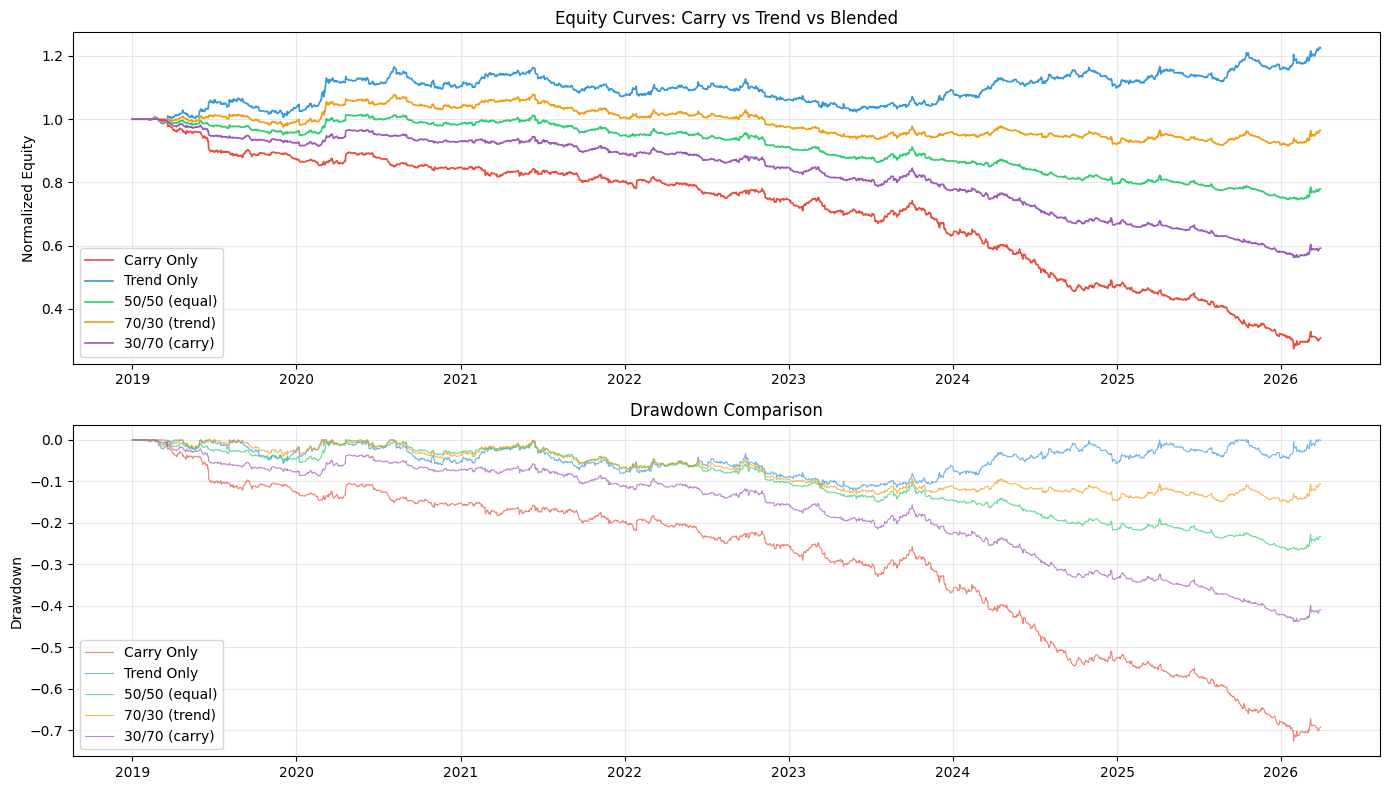

In [9]:
# 权益曲线对比图
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 权益曲线
ax = axes[0]
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
for (name, eq), color in zip(equity_curves.items(), colors):
    normalized = eq / eq.iloc[0]  # 归一化到 1 起点
    ax.plot(normalized.index, normalized.values, label=name, linewidth=1.2, color=color)
ax.set_ylabel("Normalized Equity")
ax.set_title("Equity Curves: Carry vs Trend vs Blended")
ax.legend()
ax.grid(True, alpha=0.3)

# 回撤对比
ax = axes[1]
for (name, eq), color in zip(equity_curves.items(), colors):
    cummax = eq.cummax()
    dd = (eq - cummax) / cummax
    ax.plot(dd.index, dd.values, label=name, linewidth=0.8, color=color, alpha=0.7)
ax.set_ylabel("Drawdown")
ax.set_title("Drawdown Comparison")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 滚动相关性分析

Carry 和趋势信号的相关性是否稳定？还是在不同市场环境下变化很大？

如果相关性不稳定（时而正、时而负），说明 carry 在不同环境下提供不同的分散化价值。

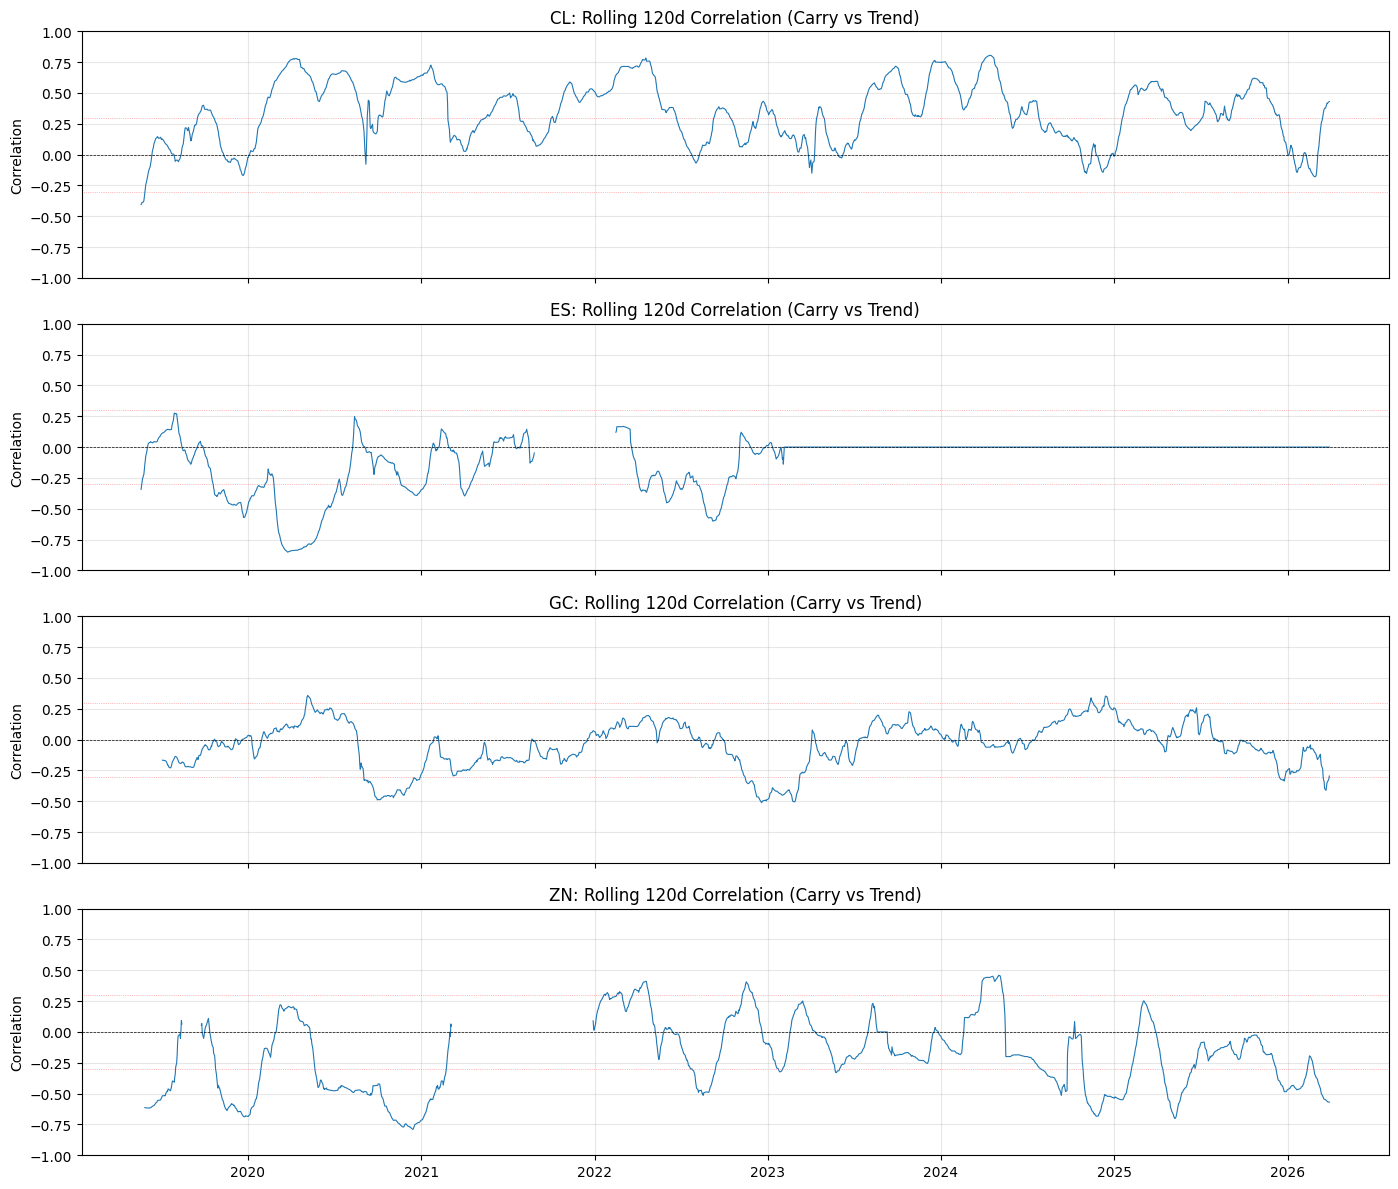

In [10]:
# 滚动相关性：carry vs combined_momentum，每个品种
fig, axes = plt.subplots(len(carry_signals), 1, figsize=(14, 3 * len(carry_signals)), sharex=True)

rolling_window = 120  # ~6 months

for i, name in enumerate(sorted(carry_signals.keys())):
    if name not in trend_signals:
        continue
    
    c_sig = carry_signals[name]
    t_sig = trend_signals[name]
    common = c_sig.index.intersection(t_sig.index)
    
    rolling_corr = c_sig.loc[common].rolling(rolling_window).corr(t_sig.loc[common])
    
    ax = axes[i]
    ax.plot(rolling_corr.index, rolling_corr.values, linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.axhline(0.3, color="red", linewidth=0.5, linestyle=":", alpha=0.5)
    ax.axhline(-0.3, color="red", linewidth=0.5, linestyle=":", alpha=0.5)
    ax.set_ylim(-1, 1)
    ax.set_ylabel("Correlation")
    ax.set_title(f"{name}: Rolling {rolling_window}d Correlation (Carry vs Trend)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 分品种 Carry 回测详情

看看 carry 在哪些品种上有效、哪些无效，帮助理解 carry 因子的经济学直觉。

经验上的预期：
- **CL (原油)**：经常处于 contango（存储成本高），carry 信号应该比较活跃
- **GC (黄金)**：通常接近 contango（持有成本 ≈ 利率），carry 值可能较小
- **ZN (国债)**：carry 反映利率期限结构，可能有独立信息
- **ES (股指)**：carry 反映股息率 vs 融资成本，值通常较小

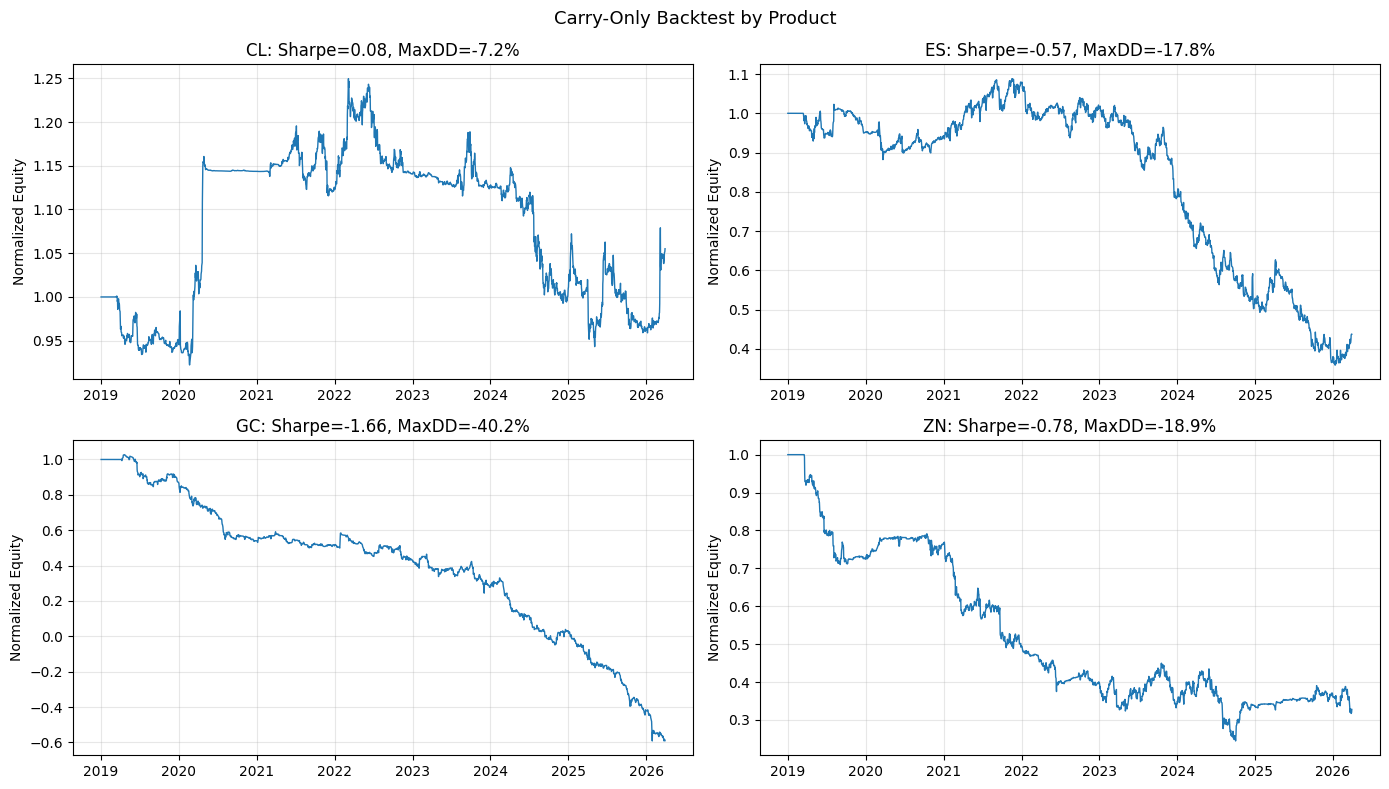

In [11]:
# 分品种 carry backtest + equity curve
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, name in enumerate(sorted(carry_product_metrics.keys())):
    ax = axes[idx // 2, idx % 2]
    m = carry_product_metrics[name]
    
    # 单品种 carry 回测
    daily = price_data[name]
    params = PRODUCTS[name]
    signal = carry_signals[name]
    
    position = volatility_sized_position(
        signal=signal,
        high=daily["high"], low=daily["low"], close=daily["close"],
        capital=INITIAL_CAPITAL,
        risk_fraction=0.01,  # 单品种用全额
        point_value=params["point_value"],
    )
    
    result = run_backtest(
        daily_price=daily, position=position,
        point_value=params["point_value"],
        commission_per_contract=params["commission"],
        slippage_points=params["slippage_points"],
        initial_capital=INITIAL_CAPITAL,
    )
    
    eq = result["equity"]
    normalized = eq / eq.iloc[0]
    ax.plot(normalized.index, normalized.values, linewidth=1)
    ax.set_title(f"{name}: Sharpe={m['sharpe_ratio']:.2f}, MaxDD={m['max_drawdown']:.1%}")
    ax.grid(True, alpha=0.3)
    ax.set_ylabel("Normalized Equity")

plt.suptitle("Carry-Only Backtest by Product", fontsize=13)
plt.tight_layout()
plt.show()

## 7. 多趋势信号 + Carry 的组合扫描

除了 combined_momentum，也尝试和其他趋势信号组合，看哪个组合效果最好。

In [12]:
# 对每个趋势信号，做 50/50 carry+trend 组合
scan_results = []

for t_name in trend_signal_names:
    # trend only
    t_signals = {}
    for name in carry_signals.keys():
        if name in price_data:
            t_signals[name] = generate_signal(price_data[name], t_name)
    
    _, t_metrics, _ = backtest_signal_portfolio(t_signals, price_data, PRODUCTS)
    scan_results.append({
        "Strategy": f"{t_name} (trend only)",
        "Sharpe": t_metrics["sharpe_ratio"],
        "Annual Return": t_metrics["annual_return"],
        "Max Drawdown": t_metrics["max_drawdown"],
        "Calmar": t_metrics["calmar_ratio"],
    })
    
    # 50/50 blend with carry
    blended = {}
    for name in carry_signals.keys():
        if name not in price_data or name not in t_signals:
            continue
        common = carry_signals[name].index.intersection(t_signals[name].index)
        blended[name] = (0.5 * t_signals[name].loc[common] + 0.5 * carry_signals[name].loc[common]).clip(-1, 1)
    
    _, b_metrics, _ = backtest_signal_portfolio(blended, price_data, PRODUCTS)
    scan_results.append({
        "Strategy": f"{t_name} + carry (50/50)",
        "Sharpe": b_metrics["sharpe_ratio"],
        "Annual Return": b_metrics["annual_return"],
        "Max Drawdown": b_metrics["max_drawdown"],
        "Calmar": b_metrics["calmar_ratio"],
    })

# carry only
scan_results.append({
    "Strategy": "carry only",
    "Sharpe": carry_portfolio_metrics["sharpe_ratio"],
    "Annual Return": carry_portfolio_metrics["annual_return"],
    "Max Drawdown": carry_portfolio_metrics["max_drawdown"],
    "Calmar": carry_portfolio_metrics["calmar_ratio"],
})

scan_df = pd.DataFrame(scan_results)
scan_df["Annual Return"] = scan_df["Annual Return"].map(lambda x: f"{x:.2%}")
scan_df["Max Drawdown"] = scan_df["Max Drawdown"].map(lambda x: f"{x:.2%}")
scan_df["Sharpe"] = scan_df["Sharpe"].round(2)
scan_df["Calmar"] = scan_df["Calmar"].round(2)

print(scan_df.to_string(index=False))
scan_df

                         Strategy  Sharpe Annual Return Max Drawdown  Calmar
            momentum (trend only)    0.13         0.92%      -15.63%    0.06
         momentum + carry (50/50)   -0.79        -3.63%      -34.55%   -0.11
   combined_momentum (trend only)    0.43         2.30%      -12.27%    0.19
combined_momentum + carry (50/50)   -0.70        -2.75%      -26.60%   -0.10
                macd (trend only)   -0.24        -1.07%      -17.91%   -0.06
             macd + carry (50/50)   -1.26        -5.27%      -41.65%   -0.13
        ma_crossover (trend only)    0.91         5.00%       -9.47%    0.53
     ma_crossover + carry (50/50)   -0.18        -0.71%      -14.90%   -0.05
            donchian (trend only)    0.31         1.59%       -6.66%    0.24
         donchian + carry (50/50)   -0.82        -3.23%      -28.94%   -0.11
           bollinger (trend only)    0.16         0.76%       -8.66%    0.09
        bollinger + carry (50/50)   -1.00        -3.92%      -33.35%   -0.12

,Strategy,Sharpe,Annual Return,Max Drawdown,Calmar
0,momentum (trend only),0.13,0.92%,-15.63%,0.06
1,momentum + carry (50/50),-0.79,-3.63%,-34.55%,-0.11
2,combined_momentum (trend only),0.43,2.30%,-12.27%,0.19
3,combined_momentum + carry (50/50),-0.70,-2.75%,-26.60%,-0.10
4,macd (trend only),-0.24,-1.07%,-17.91%,-0.06
5,macd + carry (50/50),-1.26,-5.27%,-41.65%,-0.13
6,ma_crossover (trend only),0.91,5.00%,-9.47%,0.53
7,ma_crossover + carry (50/50),-0.18,-0.71%,-14.90%,-0.05
8,donchian (trend only),0.31,1.59%,-6.66%,0.24
9,donchian + carry (50/50),-0.82,-3.23%,-28.94%,-0.11


## 8. 结论

### 相关性验证：成功

| 对比 | 平均 \|相关系数\| |
|------|-------------------|
| 趋势-趋势 | 0.63 |
| Carry-趋势 | 0.03~0.16 |

Carry 和趋势信号确实来自不同数据源（期限结构 vs 价格走势），相关性极低。"不同数据源 = 低相关"的假设得到验证。

### Carry 单因子表现：失败

| 品种 | Sharpe | MaxDD |
|------|--------|-------|
| CL | 0.08 | -7.2% |
| ES | -0.57 | -17.8% |
| GC | -1.66 | -40.2% |
| ZN | -0.78 | -18.9% |
| **组合** | **-1.30** | **-72.6%** |

Carry 在当前 4 个品种上是负 alpha 的。

### 多因子组合：被 carry 拖累

所有 carry + trend 的组合 Sharpe 都低于纯趋势。最佳趋势信号 ma_crossover（Sharpe 0.91）加入 carry 后降到 -0.18。

### 核心教训

**低相关 ≠ 有价值。** 多因子组合要有效，需要两个条件同时满足：
1. 因子之间低相关 ✓
2. 每个因子本身有正的期望收益 ✗

Carry 满足条件 1 但不满足条件 2，所以组合反而更差。

### 为什么 carry 在这里不 work

1. **品种太少**：学术文献中 carry 通常需要 20+ 品种的截面才有效（做多高 carry、做空低 carry）
2. **时间序列 vs 截面**：我们用的是纯时间序列 carry（单品种做多/做空），经典 carry 策略是截面的
3. **噪音**：4 个品种的期限结构信号噪音大，归一化后的信号可能不稳定

### 下一步

等项目五扩展到 10+ 品种后，再尝试截面 carry 策略。更多品种 = 更稳定的截面信号 + 更好的分散化。